# Exploration and EDA

This notebook connects to PostgreSQL, loads the historical extracted claims table, and explores fraud rate, amount behavior, category effects, temporal patterns, and suspicious providers.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
from src.db.query_from_postgres import fetch_historical_claims
from src.config import PostgresSettings
from src.data_engin.clean_locations import (
    DEFAULT_CITY_ADM1_MAP,
    DEFAULT_MANUAL_MISSING,
    prepare_claims_location_mapping,
    load_city_gazetteer_from_dbf,
    plot_fraud_map,
    build_map_geodf,
    aggregate_fraud_for_map,
)


## Load Historical Dataset

The historical split is the 90% earlier window of the synthetic timeline. It is built from extracted client packages and is the only subset loaded into PostgreSQL for development work.

In [3]:
claims = fetch_historical_claims(settings=PostgresSettings.from_env())
claims['claim_month'] = claims['claim_date'].dt.to_period('M').astype(str)
claims.shape, claims['claim_date'].min(), claims['claim_date'].max(), claims['is_fraud'].mean()

((54248, 16),
 Timestamp('2018-01-15 00:00:00'),
 Timestamp('2024-10-02 00:00:00'),
 np.float64(0.07015926854446247))

## Core Data Checks

These quick checks verify row counts, date coverage, null patterns, and whether the fraud target looks reasonably imbalanced for a fraud-screening workflow.

In [4]:
claims[['claim_amount', 'policy_age_days', 'num_previous_claims', 'time_since_last_claim_days']].describe().T

,count,mean,std,min,25%,50%,75%,max
policy_age_days,54248.0,710.986506,559.580789,7.0,240.0,589.0,1065.0,2462.0
num_previous_claims,54248.0,3.620779,3.187664,0.0,1.0,3.0,5.0,17.0
time_since_last_claim_days,45452.0,176.073352,128.721351,5.0,78.0,161.0,250.0,1318.0


In [5]:
fraud_rate = claims['is_fraud'].mean()
amount_summary = claims.groupby('is_fraud')['claim_amount'].agg(['mean', 'median', 'max']).round(2)
print(f"Overall Fraud Rate: {fraud_rate:.2%}")
print()
print("Claim Amount Summary by Fraud Status:")
print(amount_summary)

Overall Fraud Rate: 7.02%

Claim Amount Summary by Fraud Status:
                  mean   median       max
is_fraud                                 
False      6336.648995  4031.71  85000.00
True      15643.649887  8541.45  85000.00


## Claim Amount Behavior

Fraudulent claims were intentionally simulated to be higher value on average, but the overlap should still be large enough to avoid a trivial classification problem.

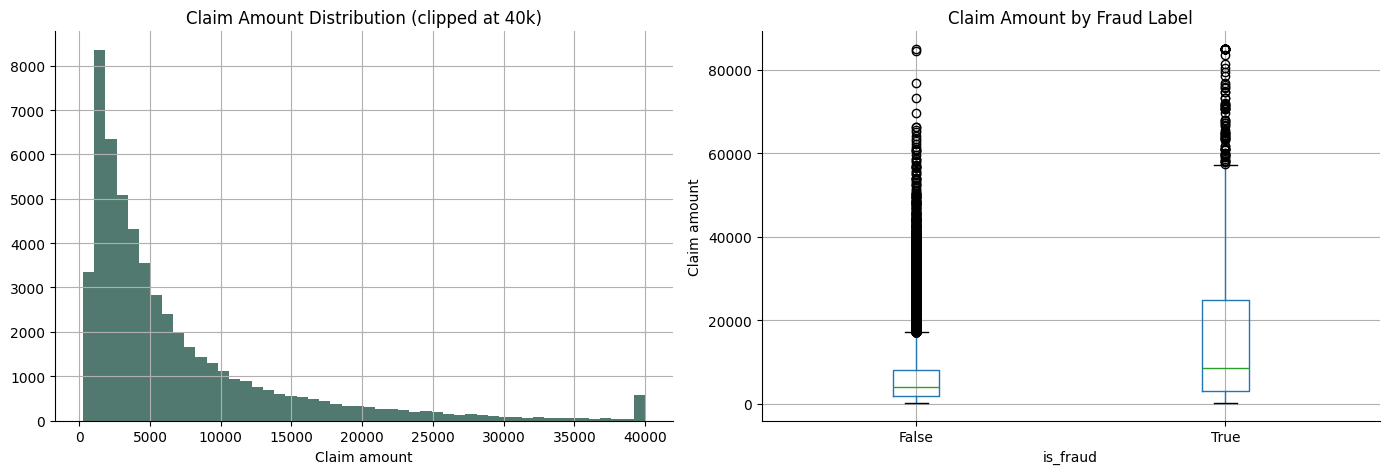

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
claims['claim_amount'].clip(upper=40000).hist(ax=axes[0], bins=50, color='#52796f')
axes[0].set_title('Claim Amount Distribution (clipped at 40k)')
axes[0].set_xlabel('Claim amount')
claims['claim_amount'] = claims['claim_amount'].apply(float)
claims.boxplot(column='claim_amount', by='is_fraud', ax=axes[1])
axes[1].set_title('Claim Amount by Fraud Label')
axes[1].set_xlabel('is_fraud')
axes[1].set_ylabel('Claim amount')
plt.suptitle('')
for sp in ['top', 'right']:
    axes[0].spines[sp].set_visible(False)
    axes[1].spines[sp].set_visible(False)
plt.tight_layout()

## Fraud by Category

Fraud rates should vary by claim type, location, and provider. That variation is a key part of the synthetic design.

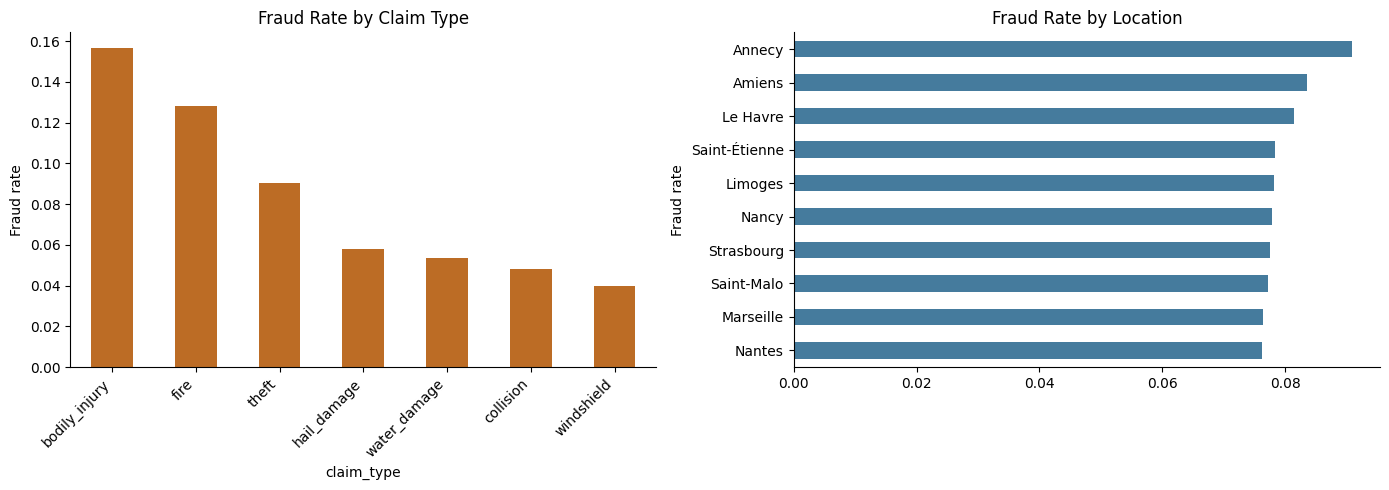

In [40]:
fraud_by_claim_type = claims.groupby('claim_type')['is_fraud'].mean().sort_values(ascending=False)
fraud_by_location = claims.groupby("location")["is_fraud"].mean()
top10_locations = fraud_by_location.nlargest(10).sort_values()  # sort_values() -> joli ordre en barh

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fraud_by_claim_type.plot(kind='bar', ax=axes[0], color='#bc6c25')
axes[0].set_title('Fraud Rate by Claim Type')
axes[0].set_ylabel('Fraud rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
top10_locations.plot(kind='barh', ax=axes[1], color='#457b9d')
axes[1].set_title('Fraud Rate by Location')
axes[1].set_ylabel('Fraud rate')
# axes[1].set_yscale('log')  # Log scale for better visibility of difference
for sp in ['top', 'right']:
    axes[0].spines[sp].set_visible(False)
    axes[1].spines[sp].set_visible(False)
plt.tight_layout()

In [8]:
dbf_path = PROJECT_ROOT / "data/other/FRA.dbf"

claims_map, city_reference = prepare_claims_location_mapping(
    claims,
    dbf_path=dbf_path,
    city_adm1_map=DEFAULT_CITY_ADM1_MAP,
    manual_missing=DEFAULT_MANUAL_MISSING,
)

cities = load_city_gazetteer_from_dbf(dbf_path)
map_df = claims_map

display(
    map_df[["location", "location_clean", "NAME", "ADM1", "ADM2", "LAT", "LONG"]]
    .drop_duplicates()
    .sort_values("location")
    .head(10)
)

print("Lignes sans coordonnées :", int(map_df["LAT"].isna().sum()))

,location,location_clean,NAME,ADM1,ADM2,LAT,LONG
0,Aix-en-Provence,aix en provence,Aix-en-Provence,PROVENCE-ALPES-COTE D'AZUR,BOUCHES-DU-RHONE,43.5333,5.4333
13,Ajaccio,ajaccio,Ajaccio,,,41.9166,8.7333
69,Amiens,amiens,Amiens,PICARDIE,SOMME,49.9000,2.3000
19,Angers,angers,Angers,PAYS DE LA LOIRE,MAINE-ET-LOIRE,47.4666,-0.5500
101,Annecy,annecy,Annecy,RHONE-ALPES,HAUTE-SAVOIE,45.9000,6.1166
35,Bordeaux,bordeaux,Bordeaux,AQUITAINE,GIRONDE,44.8333,-0.5666
14,Brest,brest,Brest,BRETAGNE,FINISTERE,48.4000,-4.4833
15,Caen,caen,Caen,BASSE-NORMANDIE,CALVADOS,49.1833,-0.3500
1,Cannes,cannes,Cannes,PROVENCE-ALPES-COTE D'AZUR,ALPES-MARITIMES,43.5500,7.0166
45,Clermont-Ferrand,clermont ferrand,Clermont-Ferrand,AUVERGNE,PUY-DE-DOME,45.7833,3.0833


Lignes sans coordonnées : 0


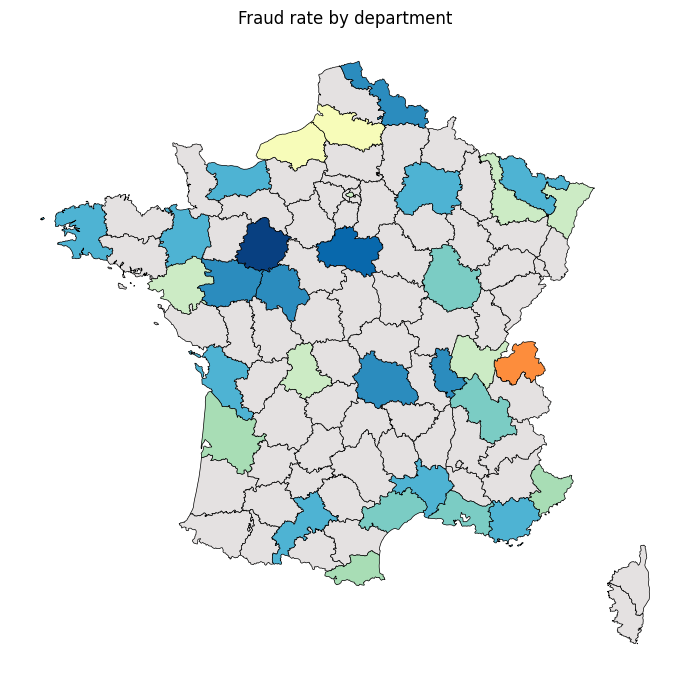

In [34]:
dep_gdf = build_map_geodf(
    map_df,
    level="dep",
    geo_path=PROJECT_ROOT / "data/other/departements.geojson",
    geo_name_col="nom",
)

fig, ax = plt.subplots(figsize=(7, 7))

dep_gdf.plot(
    ax=ax,
    color=dep_gdf["color"],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_title("Fraud rate by department")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Suspicious Providers

Providers with elevated fraud rate and enough historical volume are natural candidates for feature engineering and downstream investigations.

In [37]:
provider_summary = (
    claims.groupby('service_provider_id')
    .agg(claims=('claim_id', 'size'), fraud_rate=('is_fraud', 'mean'))
    .query('claims >= 40') # filter to providers with at least 40 claims
    .sort_values(['fraud_rate', 'claims'], ascending=[False, False])
    .head(10)
)
provider_summary

,claims,fraud_rate
service_provider_id,,
SP-017,1673,0.129707
SP-003,1492,0.129357
SP-071,1751,0.127927
SP-058,1729,0.126663
SP-111,1508,0.125332
SP-044,1771,0.124224
SP-089,1666,0.115246
SP-115,270,0.096296
SP-013,418,0.086124


## Temporal Patterns

Because the dataset is strictly split by time, it is useful to review how the fraud rate and claim counts evolve by month.

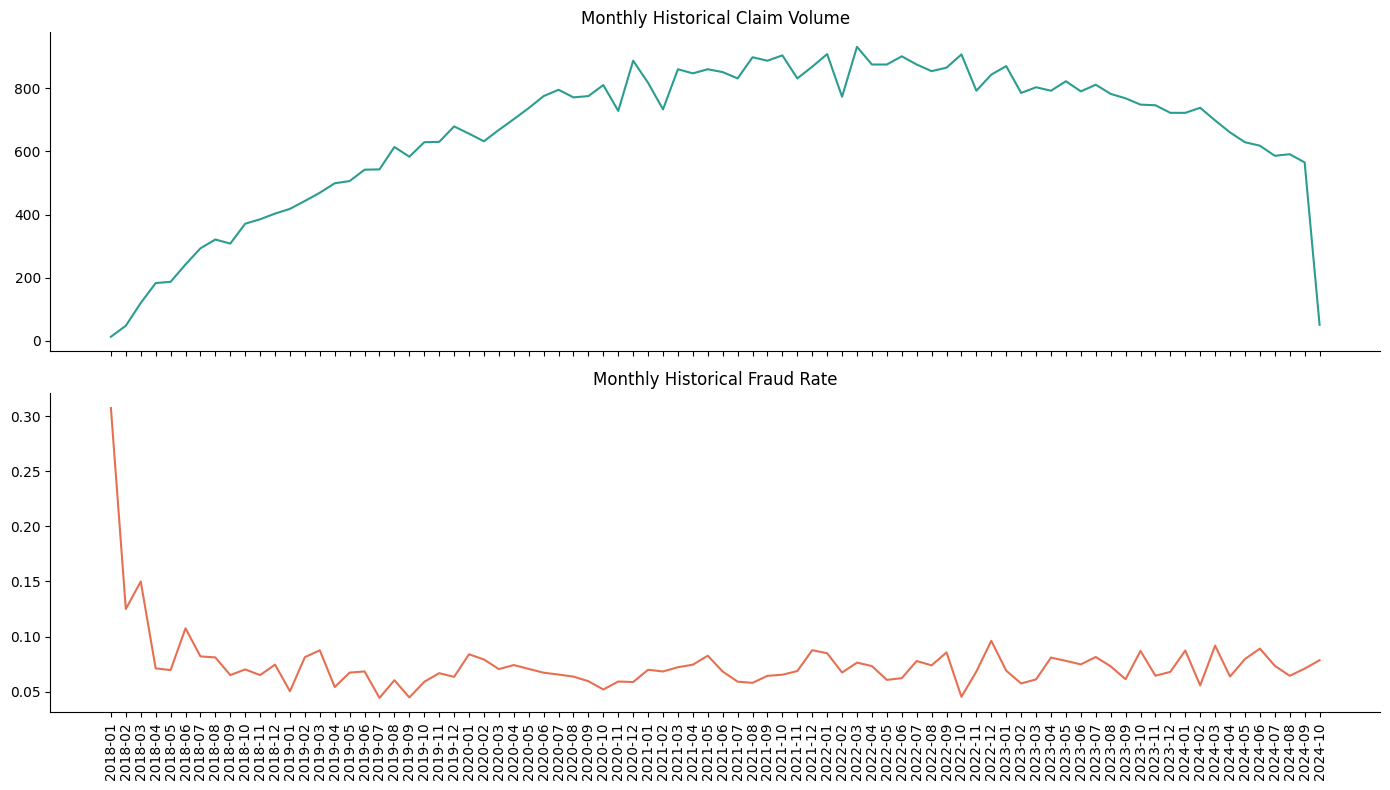

In [39]:
monthly = claims.groupby('claim_month').agg(claims=('claim_id', 'size'), fraud_rate=('is_fraud', 'mean')).reset_index()
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(monthly['claim_month'], monthly['claims'], color='#2a9d8f')
axes[0].set_title('Monthly Historical Claim Volume')
axes[0].tick_params(axis='x', rotation=90)
axes[1].plot(monthly['claim_month'], monthly['fraud_rate'], color='#e76f51')
axes[1].set_title('Monthly Historical Fraud Rate')
axes[1].tick_params(axis='x', rotation=90)
for sp in ['top', 'right']:
    axes[0].spines[sp].set_visible(False)
    axes[1].spines[sp].set_visible(False)
plt.tight_layout()

## Commentary

The historical fraud rate is intentionally low, but not vanishingly rare. Claim amount, provider identity, short time gaps between claims, and specific claim categories contribute visible structure. Those same patterns are later reused in feature engineering and counterfactual analysis.